# Notebook 00 — SQL Fleet Analysis with DuckDB

DuckDB queries Waymo parquet files directly — no loading into memory first.
This demonstrates SQL proficiency at scale, which is a core requirement
for the Waymo Data Scientist role.

Queries cover:
1. Fleet-level agent statistics
2. Near-miss event ranking by segment
3. Speed distribution by object type
4. Top-N most dangerous frames
5. Temporal trend analysis
6. Window functions for rolling safety metrics

In [1]:
import sys
sys.path.insert(0, '..')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# DuckDB in-memory connection
con = duckdb.connect()
print(f'DuckDB version: {duckdb.__version__}')

DuckDB version: 1.5.3


In [2]:
# Discover parquet files — files live in data/<split>/lidar_box/<segment_id>.parquet
lb_files = glob.glob('../data/**/lidar_box/*.parquet', recursive=True)
print(f'Found {len(lb_files)} lidar_box parquet files')

if not lb_files:
    raise FileNotFoundError(
        'No parquet files found. Run: python src/data/download.py --num_segments 5'
    )

# Register the parquet glob as a virtual table
con.execute("CREATE VIEW lidar_box AS SELECT * FROM read_parquet('../data/**/lidar_box/*.parquet', hive_partitioning=false)")

# Show schema
con.execute('DESCRIBE lidar_box').df()

Found 10 lidar_box parquet files


,column_name,column_type,null,key,default,extra
0,index,VARCHAR,YES,None,None,None
1,key.segment_context_name,VARCHAR,YES,None,None,None
2,key.frame_timestamp_micros,BIGINT,YES,None,None,None
3,key.laser_object_id,VARCHAR,YES,None,None,None
4,[LiDARBoxComponent].box.center.x,DOUBLE,YES,None,None,None
5,[LiDARBoxComponent].box.center.y,DOUBLE,YES,None,None,None
6,[LiDARBoxComponent].box.center.z,DOUBLE,YES,None,None,None
7,[LiDARBoxComponent].box.size.x,DOUBLE,YES,None,None,None
8,[LiDARBoxComponent].box.size.y,DOUBLE,YES,None,None,None
9,[LiDARBoxComponent].box.size.z,DOUBLE,YES,None,None,None


## Query 1 — Fleet-level agent statistics

In [3]:
fleet_stats = con.execute("""
    SELECT
        -- Determine column names dynamically from what's available
        COUNT(*)                                          AS total_detections,
        COUNT(DISTINCT "key.segment_context_name")       AS n_segments,
        COUNT(DISTINCT "key.frame_timestamp_micros")     AS n_frames
    FROM lidar_box
""").df()
print('Fleet overview:')
fleet_stats

Fleet overview:


,total_detections,n_segments,n_frames
0,109776,10,1967


In [4]:
# Load data through our loader (which handles column renaming)
from src.data.waymo_loader import load_dataset, extract_trajectories
from src.metrics.safety_metrics import batch_ttc, nearest_agent_distances

dataset = load_dataset('../data', max_segments=10)
lb = dataset['lidar_box']
trajectories = extract_trajectories(lb)
trajectories = nearest_agent_distances(trajectories)
ttc_df = batch_ttc(trajectories)

# Register DataFrames with DuckDB for SQL querying
con.register('traj', trajectories)
con.register('ttc', ttc_df)
print('Registered DataFrames: traj, ttc')

Registered DataFrames: traj, ttc


/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: invalid value encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: divide by zero encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)


## Query 2 — Agent count and speed by type

In [5]:
agent_stats = con.execute("""
    SELECT
        object_type_name,
        COUNT(*)                    AS n_observations,
        COUNT(DISTINCT object_id)   AS n_unique_agents,
        ROUND(AVG(speed), 3)        AS mean_speed_mps,
        ROUND(STDDEV(speed), 3)     AS std_speed_mps,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY speed), 3) AS median_speed_mps,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY speed), 3) AS p95_speed_mps,
        ROUND(MAX(speed), 3)        AS max_speed_mps
    FROM traj
    WHERE speed IS NOT NULL AND speed >= 0
    GROUP BY object_type_name
    ORDER BY n_observations DESC
""").df()
print('Agent statistics by type:')
agent_stats

Agent statistics by type:


,object_type_name,n_observations,n_unique_agents,mean_speed_mps,std_speed_mps,median_speed_mps,p95_speed_mps,max_speed_mps
0,vehicle,51850,511,1.4920,4.2310,0.0000,11.1940,25.2130
1,cyclist,37732,390,0.0170,0.0200,0.0100,0.0630,0.2500
2,pedestrian,18010,165,1.1420,0.6510,1.2910,1.7070,7.0080
3,sign,1101,13,4.7300,1.4810,4.5640,7.7070,9.1650


## Query 3 — Near-miss ranking by segment

In [6]:
near_miss_ranking = con.execute("""
    SELECT
        segment_id,
        COUNT(*)                                                   AS total_frames,
        SUM(CASE WHEN near_miss THEN 1 ELSE 0 END)                AS near_miss_count,
        ROUND(100.0 * SUM(CASE WHEN near_miss THEN 1 ELSE 0 END)
              / COUNT(*), 2)                                       AS near_miss_rate_pct,
        ROUND(MIN(CASE WHEN min_ttc < 1e9 THEN min_ttc END), 3)  AS min_ttc_observed_s,
        ROUND(AVG(CASE WHEN min_ttc < 1e9 THEN min_ttc END), 3)  AS mean_min_ttc_s
    FROM ttc
    GROUP BY segment_id
    ORDER BY near_miss_rate_pct DESC
""").df()
print('Near-miss ranking by segment (most dangerous first):')
near_miss_ranking

Near-miss ranking by segment (most dangerous first):


,segment_id,total_frames,near_miss_count,near_miss_rate_pct,min_ttc_observed_s,mean_min_ttc_s
0,10203656353524179475_7625_000_7645_000,197,197.0000,100.0000,0.0000,0.2480
1,10689101165701914459_2072_300_2092_300,197,197.0000,100.0000,0.0000,0.0000
2,10448102132863604198_472_000_492_000,182,182.0000,100.0000,0.0000,0.5050
3,1024360143612057520_3580_000_3600_000,198,198.0000,100.0000,0.0000,0.0160
4,10289507859301986274_4200_000_4220_000,197,197.0000,100.0000,0.0000,0.2860
5,10837554759555844344_6525_000_6545_000,197,180.0000,91.3700,0.0000,1.0260
6,10359308928573410754_720_000_740_000,198,172.0000,86.8700,0.3000,3.7770
7,1071392229495085036_1844_790_1864_790,163,127.0000,77.9100,0.0000,3.4120
8,10335539493577748957_1372_870_1392_870,197,97.0000,49.2400,0.0990,39.1500
9,10247954040621004675_2180_000_2200_000,197,21.0000,10.6600,0.0000,84.4500


## Query 4 — Top-20 most dangerous frames (lowest TTC)

In [7]:
dangerous_frames = con.execute("""
    SELECT
        t.segment_id,
        t.timestamp_us,
        ROUND(t.min_ttc, 4)                                    AS min_ttc_s,
        ROUND(k.mean_speed, 3)                                 AS mean_speed_mps,
        ROUND(k.mean_acceleration, 3)                          AS mean_accel_mps2,
        k.n_agents
    FROM ttc t
    JOIN (
        SELECT segment_id, timestamp_us,
               AVG(speed) AS mean_speed,
               AVG(acceleration) AS mean_acceleration,
               COUNT(DISTINCT object_id) AS n_agents
        FROM traj
        GROUP BY segment_id, timestamp_us
    ) k ON t.segment_id = k.segment_id AND t.timestamp_us = k.timestamp_us
    WHERE t.min_ttc < 1e9
    ORDER BY t.min_ttc ASC
    LIMIT 20
""").df()
print('Top 20 most dangerous frames:')
dangerous_frames

Top 20 most dangerous frames:


,segment_id,timestamp_us,min_ttc_s,mean_speed_mps,mean_accel_mps2,n_agents
0,10837554759555844344_6525_000_6545_000,1522609588481339,0.0000,2.3400,0.2950,15
1,10837554759555844344_6525_000_6545_000,1522609591681493,0.0000,1.9000,0.2370,29
2,10203656353524179475_7625_000_7645_000,1522688023761906,0.0000,2.2480,0.1150,41
3,10203656353524179475_7625_000_7645_000,1522688026262000,0.0000,1.9110,0.0730,47
4,10203656353524179475_7625_000_7645_000,1522688022362675,0.0000,2.9810,0.1530,38
5,10203656353524179475_7625_000_7645_000,1522688025561840,0.0000,1.9130,0.1100,48
6,10203656353524179475_7625_000_7645_000,1522688026762150,0.0000,1.5510,0.0890,47
7,10203656353524179475_7625_000_7645_000,1522688027962675,0.0000,1.6000,0.0650,45
8,10837554759555844344_6525_000_6545_000,1522609590381076,0.0000,2.0260,0.1970,30
9,10203656353524179475_7625_000_7645_000,1522688022762410,0.0000,2.5570,0.1380,37


## Query 5 — Rolling 5-frame safety metric with window functions

In [8]:
rolling_safety = con.execute("""
    SELECT
        segment_id,
        timestamp_us,
        min_ttc,
        near_miss,
        AVG(CASE WHEN min_ttc < 1e9 THEN min_ttc END)
            OVER (PARTITION BY segment_id
                  ORDER BY timestamp_us
                  ROWS BETWEEN 4 PRECEDING AND CURRENT ROW)
            AS rolling_5_mean_ttc,
        SUM(CAST(near_miss AS INTEGER))
            OVER (PARTITION BY segment_id
                  ORDER BY timestamp_us
                  ROWS BETWEEN 4 PRECEDING AND CURRENT ROW)
            AS rolling_5_near_miss_count
    FROM ttc
    ORDER BY segment_id, timestamp_us
    LIMIT 200
""").df()
print(f'Rolling window results: {len(rolling_safety)} rows')
rolling_safety.head(10)

Rolling window results: 200 rows


,segment_id,timestamp_us,min_ttc,near_miss,rolling_5_mean_ttc,rolling_5_near_miss_count
0,10203656353524179475_7625_000_7645_000,1522688015070129,0.5499,True,0.5499,1.0000
1,10203656353524179475_7625_000_7645_000,1522688015170074,0.4401,True,0.4950,2.0000
2,10203656353524179475_7625_000_7645_000,1522688015269987,0.3776,True,0.4558,3.0000
3,10203656353524179475_7625_000_7645_000,1522688015369887,0.3590,True,0.4316,4.0000
4,10203656353524179475_7625_000_7645_000,1522688015469787,0.3801,True,0.4213,5.0000
5,10203656353524179475_7625_000_7645_000,1522688015569695,0.4387,True,0.3991,5.0000
6,10203656353524179475_7625_000_7645_000,1522688015669599,0.5311,True,0.4173,5.0000
7,10203656353524179475_7625_000_7645_000,1522688015769511,0.5820,True,0.4582,5.0000
8,10203656353524179475_7625_000_7645_000,1522688015869379,0.4563,True,0.4776,5.0000
9,10203656353524179475_7625_000_7645_000,1522688015969284,0.3854,True,0.4787,5.0000


## Query 6 — Jerk violation summary (comfort metrics)

In [9]:
jerk_summary = con.execute("""
    SELECT
        segment_id,
        object_type_name,
        COUNT(*)                                                           AS n_frames,
        ROUND(AVG(ABS(jerk)), 4)                                           AS mean_abs_jerk,
        ROUND(MAX(ABS(jerk)), 4)                                           AS max_abs_jerk,
        ROUND(100.0 * SUM(CASE WHEN ABS(jerk) > 6 THEN 1 ELSE 0 END)
              / COUNT(*), 2)                                               AS jerk_violation_pct,
        ROUND(100.0 * SUM(CASE WHEN acceleration > 4 THEN 1 ELSE 0 END)
              / COUNT(*), 2)                                               AS hard_brake_pct
    FROM traj
    WHERE jerk IS NOT NULL AND object_type_name = 'vehicle'
    GROUP BY segment_id, object_type_name
    ORDER BY jerk_violation_pct DESC
""").df()
print('Jerk and hard braking violations by segment:')
jerk_summary

Jerk and hard braking violations by segment:


,segment_id,object_type_name,n_frames,mean_abs_jerk,max_abs_jerk,jerk_violation_pct,hard_brake_pct
0,10203656353524179475_7625_000_7645_000,vehicle,3034,0.2069,6.6406,0.2300,0.0000
1,10359308928573410754_720_000_740_000,vehicle,6580,0.0986,11.5660,0.1700,0.1500
2,10448102132863604198_472_000_492_000,vehicle,4746,0.1496,8.3215,0.0800,0.0000
3,10289507859301986274_4200_000_4220_000,vehicle,9642,0.1719,24.0106,0.0700,0.0400
4,10837554759555844344_6525_000_6545_000,vehicle,2220,0.2698,12.8714,0.0500,0.6300
5,1024360143612057520_3580_000_3600_000,vehicle,7925,0.0492,14.2213,0.0100,0.0000
6,10247954040621004675_2180_000_2200_000,vehicle,3764,0.0168,1.0747,0.0000,0.0000
7,10689101165701914459_2072_300_2092_300,vehicle,10770,0.0054,1.2260,0.0000,0.0000
8,1071392229495085036_1844_790_1864_790,vehicle,1316,0.0088,0.2760,0.0000,0.0000
9,10335539493577748957_1372_870_1392_870,vehicle,1342,0.2604,2.1346,0.0000,0.0000


## Visualisation — Safety score league table

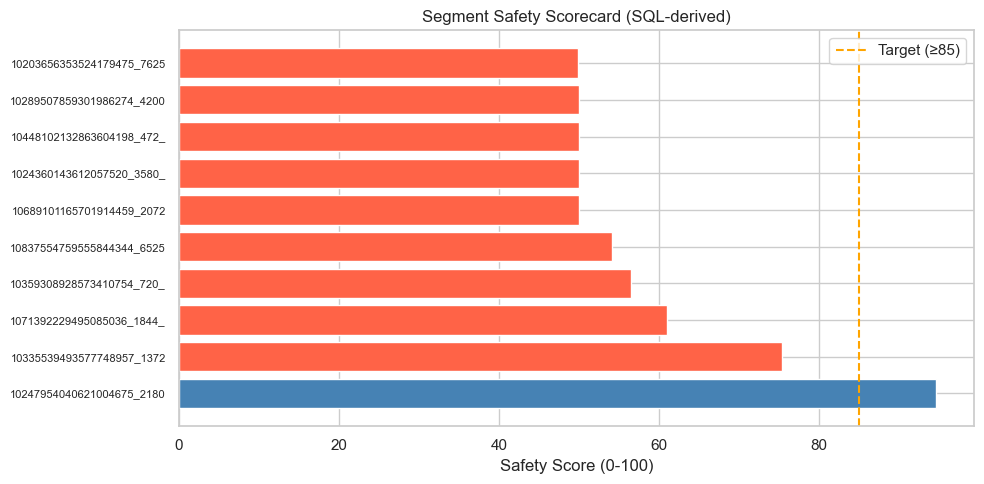

                            segment_id  near_miss_rate_pct  jerk_violation_pct  hard_brake_pct  safety_score
10247954040621004675_2180_000_2200_000             10.6600              0.0000          0.0000       94.6700
10335539493577748957_1372_870_1392_870             49.2400              0.0000          0.0000       75.3800
 1071392229495085036_1844_790_1864_790             77.9100              0.0000          0.0000       61.0500
  10359308928573410754_720_000_740_000             86.8700              0.1700          0.1500       56.4800
10837554759555844344_6525_000_6545_000             91.3700              0.0500          0.6300       54.1700
10689101165701914459_2072_300_2092_300            100.0000              0.0000          0.0000       50.0000
 1024360143612057520_3580_000_3600_000            100.0000              0.0100          0.0000       50.0000
  10448102132863604198_472_000_492_000            100.0000              0.0800          0.0000       49.9800
1028950785930198627

In [10]:
# Combine metrics into a single safety scorecard via SQL
scorecard = con.execute("""
    SELECT
        n.segment_id,
        n.near_miss_rate_pct,
        j.jerk_violation_pct,
        j.hard_brake_pct,
        ROUND(
            (100 - n.near_miss_rate_pct) * 0.5 +
            (100 - j.jerk_violation_pct) * 0.3 +
            (100 - j.hard_brake_pct) * 0.2
        , 2) AS safety_score
    FROM (
        SELECT segment_id,
               ROUND(100.0 * SUM(CASE WHEN near_miss THEN 1 ELSE 0 END) / COUNT(*), 2) AS near_miss_rate_pct
        FROM ttc GROUP BY segment_id
    ) n
    JOIN (
        SELECT segment_id,
               ROUND(100.0 * SUM(CASE WHEN ABS(jerk) > 6 THEN 1 ELSE 0 END) / COUNT(*), 2) AS jerk_violation_pct,
               ROUND(100.0 * SUM(CASE WHEN acceleration > 4 THEN 1 ELSE 0 END) / COUNT(*), 2) AS hard_brake_pct
        FROM traj WHERE object_type_name = 'vehicle' AND jerk IS NOT NULL
        GROUP BY segment_id
    ) j ON n.segment_id = j.segment_id
    ORDER BY safety_score DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if s < 85 else 'steelblue' for s in scorecard['safety_score']]
ax.barh(range(len(scorecard)), scorecard['safety_score'], color=colors, edgecolor='white')
ax.set_yticks(range(len(scorecard)))
ax.set_yticklabels([s[:25] for s in scorecard['segment_id']], fontsize=8)
ax.axvline(85, color='orange', linestyle='--', label='Target (≥85)')
ax.set_xlabel('Safety Score (0-100)')
ax.set_title('Segment Safety Scorecard (SQL-derived)')
ax.legend()
plt.tight_layout()
plt.show()

print(scorecard.to_string(index=False))